<a href="https://colab.research.google.com/github/Keerthanabs1326/Ethnotech_GenAI/blob/main/streaming_platform1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem statement: Netflix operates in a highly competitive global streaming market with diverse user preferences across countries. With a large catalog of movies and TV shows, Netflix needs to make data-driven decisions about:What type of content (Movies vs TV Shows) to produce,Which genres perform better in different countries, How content trends have changed over time, Where to invest to grow its subscriber base globally

1. Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. For styling the graphs

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
df.shape

(8807, 13)

3. Reading the netflix dataset

In [ ]:
df = pd.read_csv('/content/netflix1.csv')

4. Viewing the first 5 rows of the data set

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


5. Names of all columns and total number of Movies and TV shows in the dataset

In [ ]:
print("Columns:", df.columns)
print("Total Movies and TV Shows:", len(df))

Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
Total Movies and TV Shows: 8807


6. Diplaying a quick summary of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


7. Missing values in each column of the dataset

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


8. Statistical summary of numerical columns in the datset

In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


9. Improving the memory efficiency and categorical analysis faster

In [ ]:
cat_cols = ['type', 'rating']
for col in cat_cols:
    df[col] = df[col].astype('category')

10. Total counts of movies and TV shoes in the data set

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


11. Count of how many times the each rating appears

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


12. Number of unique countries in the dataset

In [ ]:
df['country'].nunique()

748

13. Distinct years in the dataset

In [ ]:
df['release_year'].unique()

array([2020, 2021, 1993, 2018, 1996, 1998, 1997, 2010, 2013, 2017, 1975,
       1978, 1983, 1987, 2012, 2001, 2014, 2002, 2003, 2004, 2011, 2008,
       2009, 2007, 2005, 2006, 1994, 2015, 2019, 2016, 1982, 1989, 1990,
       1991, 1999, 1986, 1992, 1984, 1980, 1961, 2000, 1995, 1985, 1976,
       1959, 1988, 1981, 1972, 1964, 1945, 1954, 1979, 1958, 1956, 1963,
       1970, 1973, 1925, 1974, 1960, 1966, 1971, 1962, 1969, 1977, 1967,
       1968, 1965, 1946, 1942, 1955, 1944, 1947, 1943])

14. Replacing missing values with empty string. Splitting a single text field into multiple values Using comma + space as separator

In [ ]:
df['cast'] = df['cast'].fillna('').str.split(', ')
df['director'] = df['director'].fillna('').str.split(', ')
df['country'] = df['country'].fillna('').str.split(', ')
df['listed_in'] = df['listed_in'].str.split(', ')

15. Taking the columns that contains list and creating 1 row per list item

In [ ]:
df_cast = df.explode('cast')
df_director = df.explode('director')
df_country = df.explode('country')
df_genre = df.explode('listed_in')

16. Graph of distribution of the release year. In this it is observed that there is limited content on netflix before the year 1980. There is a gradual increase of content after the year 2000. Sharp rise in the year after 2015 shows the rapid growth in Netflix's content. The tallest bar appears between 2015-2020

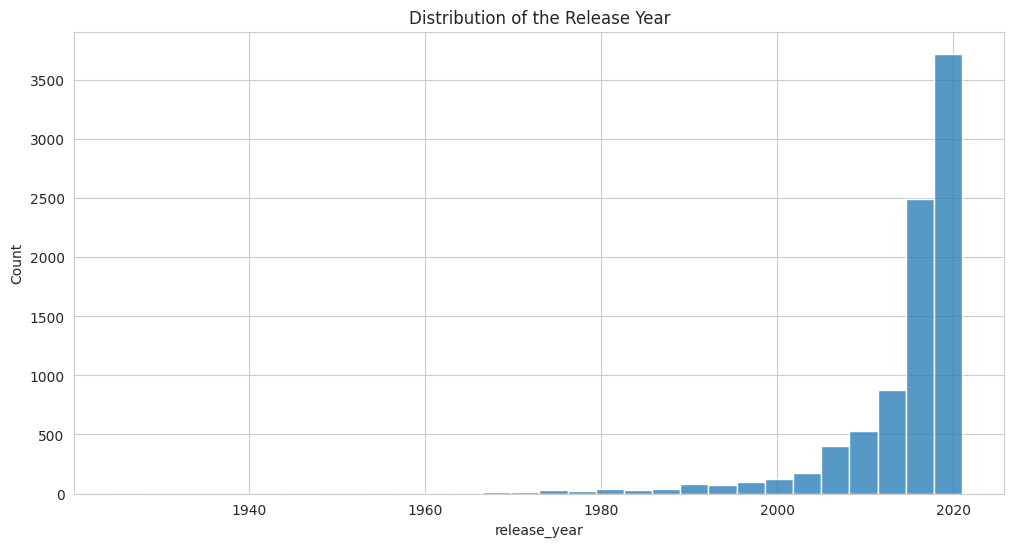

In [ ]:
sns.histplot(df['release_year'], bins=30)
plt.title("Distribution of the Release Year")
plt.show()

17.Histogram, showing the distribution of movie durations.The x-axis represents movie duration.The y-axis represents count (number of movies in each duration).The histogram is right-skewed (positively skewed), meaning most movies have shorter durations, but a few movies are much longer.The peak is roughly between 90–110 minutes, indicating most movies are around this length.The tallest bar is around 100 minutes, which seems to be the most common movie duration.Movie durations above 180–200 minutes are very rare.There are very few movies below 30 minutes, suggesting short films are uncommon in this dataset.

/tmp/ipython-input-4020832505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.replace(' min','').astype(float)


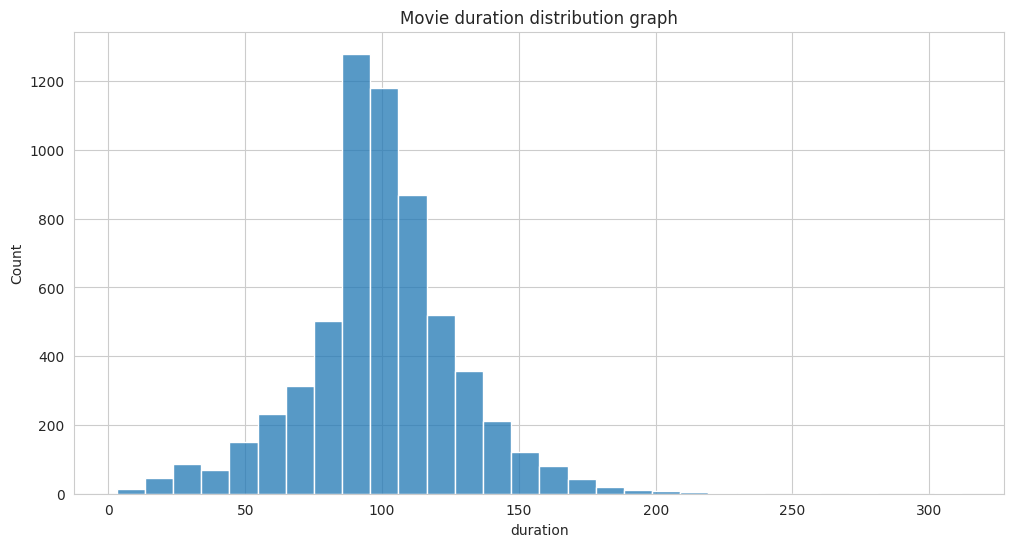

In [ ]:
movies = df[df['type']=='Movie']
movies['duration'] = movies['duration'].str.replace(' min','').astype(float)
sns.histplot(movies['duration'], bins=30)
plt.title("Movie duration distribution graph")
plt.show()

18.The bar chart you shared compares the count of Movies versus TV Shows. From the visualization:
Movies: There are approximately 6,100 entries.
TV Shows: There are approximately 2,700 entries.

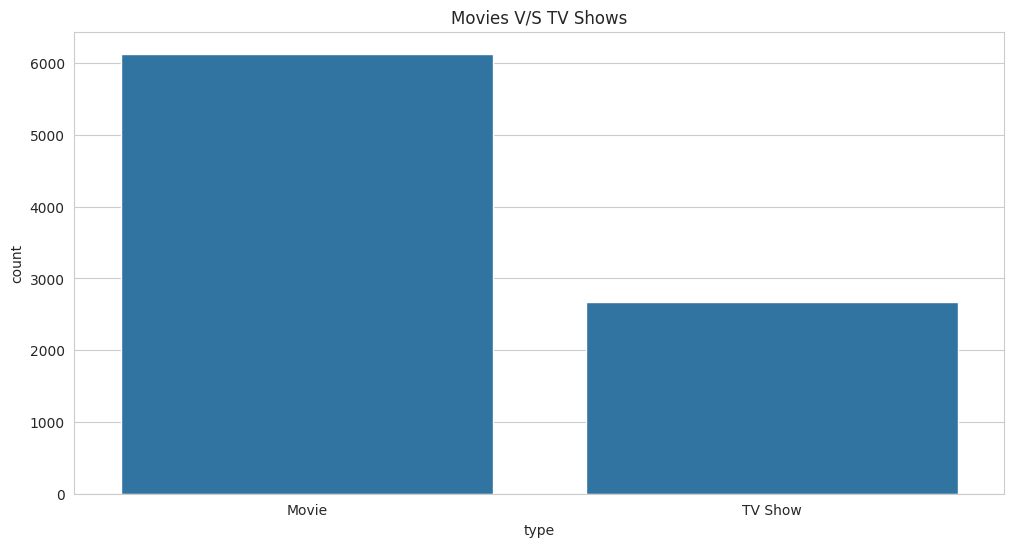

In [ ]:
sns.countplot(x='type', data=df)
plt.title("Movies V/S TV Shows")
plt.show()

19. It is observed that the most common rating is TV-MA

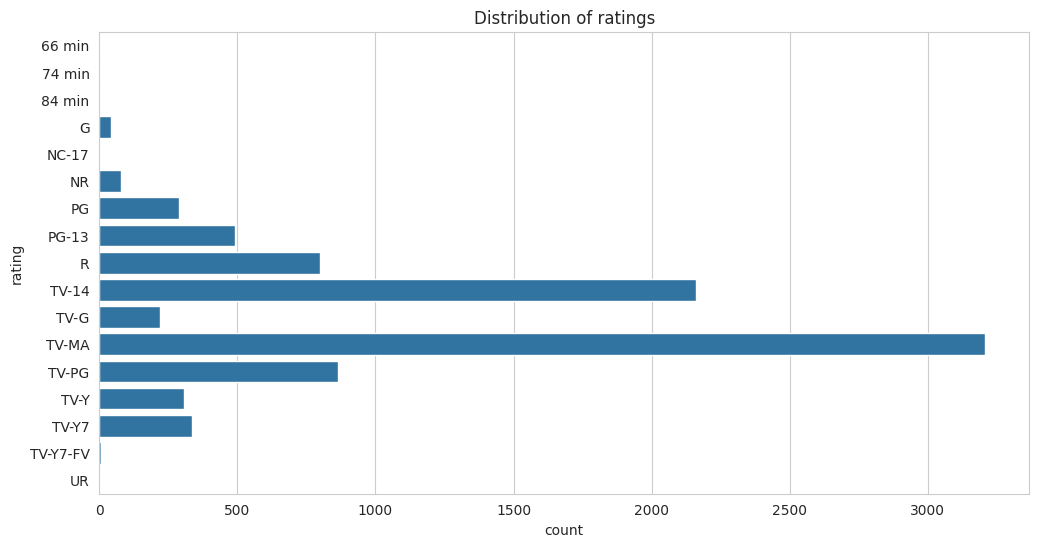

In [ ]:
sns.countplot(y='rating', data=df)
plt.title("Distribution of ratings")
plt.show()

20. Most Movies and TV Shows in your dataset are recent (2010–2020), with TV Shows skewing slightly more recent. There are a few older outliers, indicating some historical content is included.

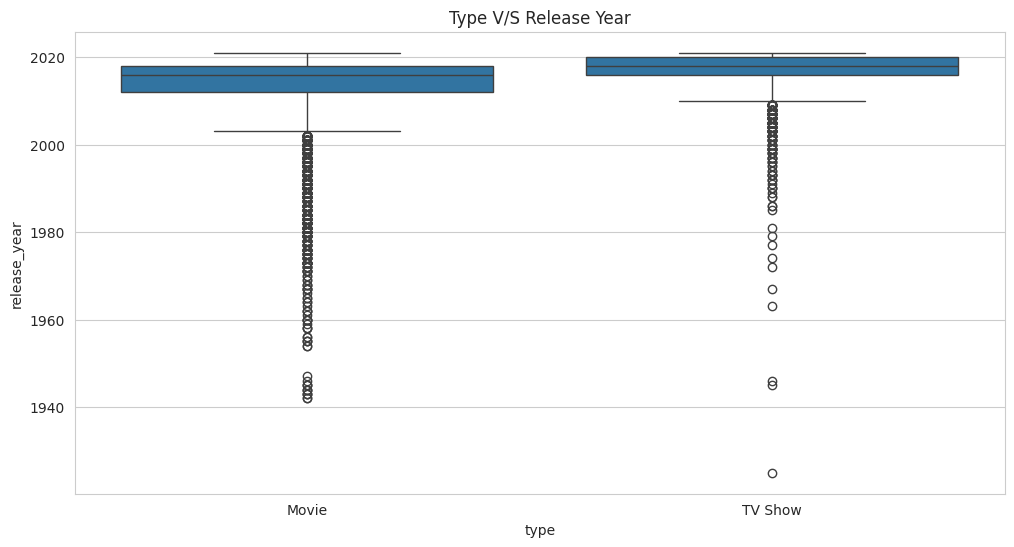

In [ ]:
sns.boxplot(x='type', y='release_year', data=df)
plt.title("Type V/S Release Year")
plt.show()

21. Movies dominate most adult-oriented ratings (R, PG-13, TV-14, TV-MA).TV shows are mostly geared toward younger audiences.The chart helps compare content distribution between movies and TV shows by their ratings.

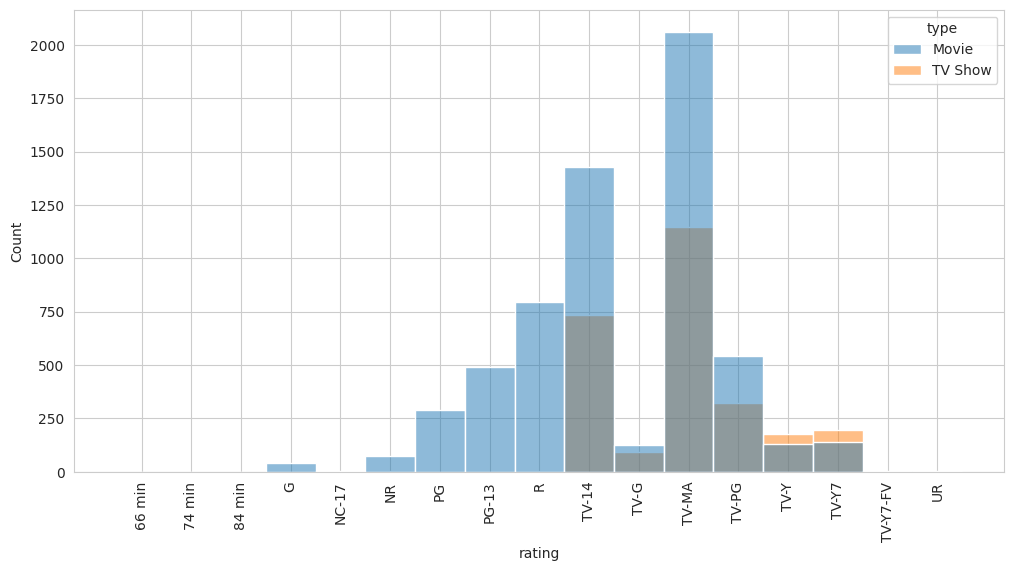

In [ ]:
sns.histplot(x='rating', hue='type', data=df)
plt.xticks(rotation=90)
plt.show()

22. It is observed that United States leads by a significant margin, producing far more content than any other country.India is the second-highest, with the bar less than a third of the U.S. United Kingdom follows closely behind India.Countries like Canada, France, and Japan contribute moderately.Spain, South Korea, Germany, Mexico, China, Australia, Egypt, and Turkey produce smaller amounts of content in comparison.The chart is a horizontal bar chart, which makes it easy to compare countries at a glance.

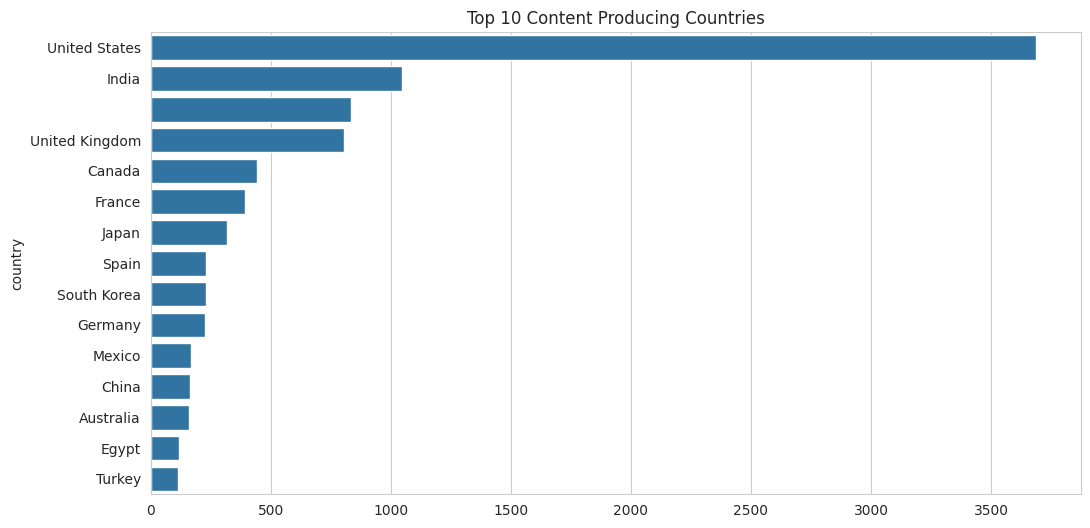

In [ ]:
top_countries = df_country['country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.show()

23.Shows a clear shift toward TV shows since 2015, making serialized content the main driver of engagement.Regional preferences are strong — Bollywood in India, Anime in Japan, and Documentaries/Comedies in the US — highlighting the need for localized production.Holiday seasons (December–January) emerge as the best launch window, while popular genres like International Movies, Dramas, and Comedies dominate globally.

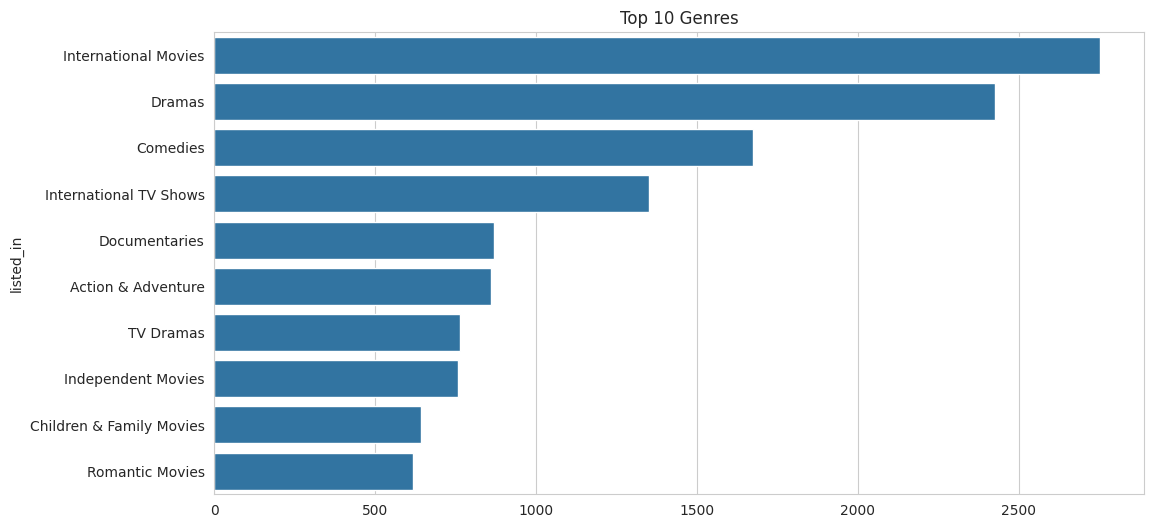

In [ ]:
top_genres = df_genre['listed_in'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.show()

24. The chart highlights the top 10 most frequently appearing actors in Netflix’s catalog, with Anupam Kher leading the list, followed by Shah Rukh Khan and Julie Tejwani.This suggests a strong representation of Indian talent, indicating Netflix’s strategic investment in Bollywood and regional content.Actors like Takahiro Sakurai and Yuki Kaji also appear, reflecting the platform’s global reach and popularity of anime.Overall, Netflix relies heavily on familiar faces to attract diverse audiences across regions.

/tmp/ipython-input-3528090822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, palette='viridis')


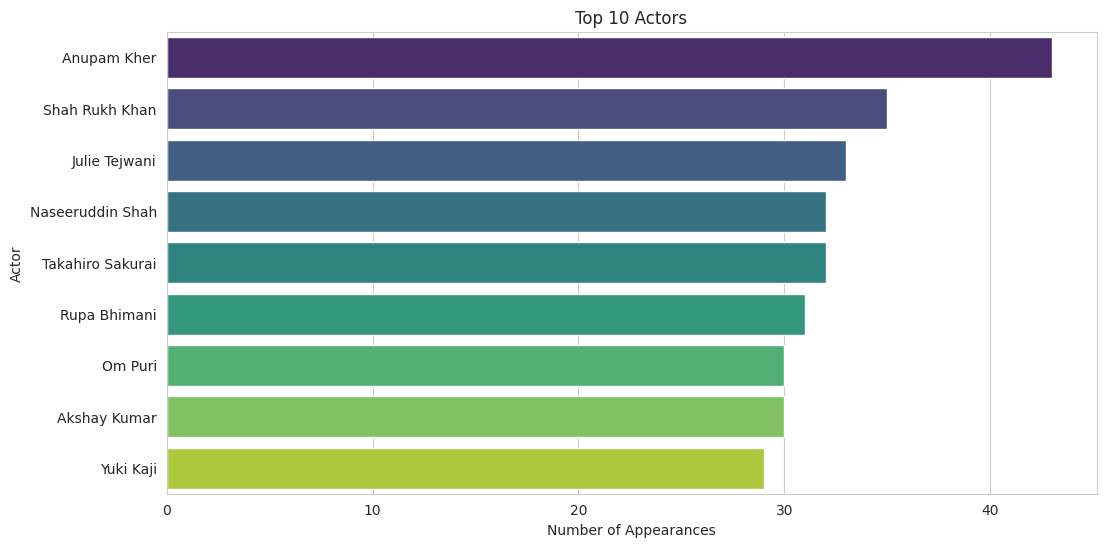

In [ ]:
top_actors = df_cast['cast'].value_counts().head(10)
top_actors = top_actors[top_actors.index != '']
sns.barplot(x=top_actors.values, y=top_actors.index, palette='viridis')
plt.title("Top 10 Actors")
plt.xlabel("Number of Appearances")
plt.ylabel("Actor")
plt.show()

25. The chart highlights the top 10 most frequently featured directors on Netflix, with Rajiv Chilaka leading the list, followed closely by Jan Suter and Raúl Campos.This suggests a strong presence of creators known for animated and regional content, especially from India and Latin America.Directors like Martin Scorsese and Youssef Chahine also appear, reflecting Netflix’s blend of mainstream and international cinema.Overall, Netflix’s catalog favors recurring collaborations with specific directors, indicating strategic partnerships to maintain consistent content output.

/tmp/ipython-input-51420871.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')


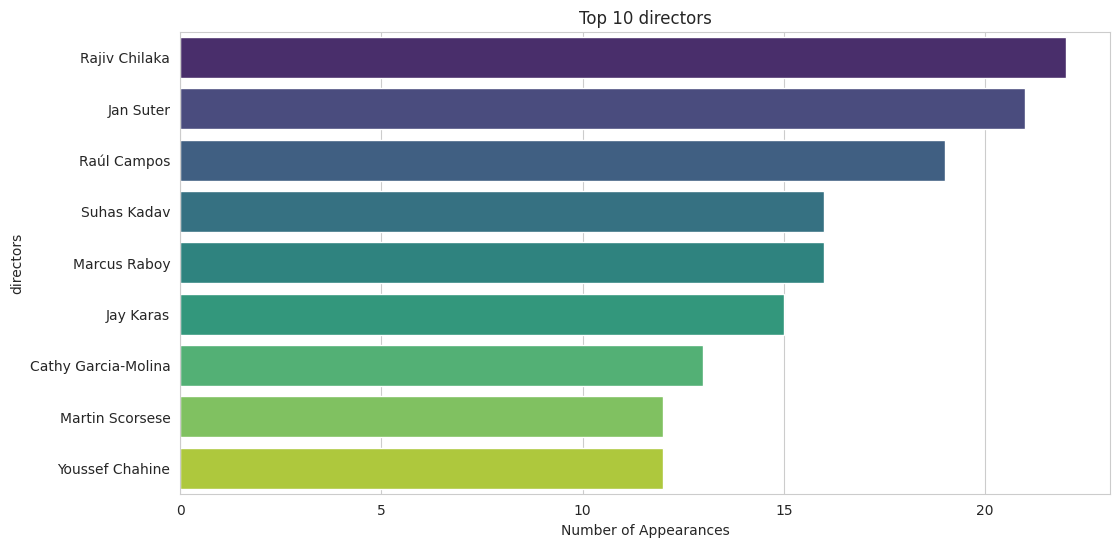

In [ ]:
top_directors = df_director['director'].value_counts().head(10)
top_directors = top_directors[top_directors.index != '']
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')
plt.title("Top 10 directors")
plt.xlabel("Number of Appearances")
plt.ylabel("directors")
plt.show()

26. The box plot reveals that most movies on Netflix have durations clustered between approximately 60 and 120 minutes, with a median around 90 minutes.Several outliers exist on both ends — extremely short films and unusually long ones exceeding 200 minutes.This suggests that while Netflix favors standard-length movies, it also includes niche content like short films and extended features.
Understanding this range helps tailor recommendations and production strategies to match viewer preferences and attention spans.

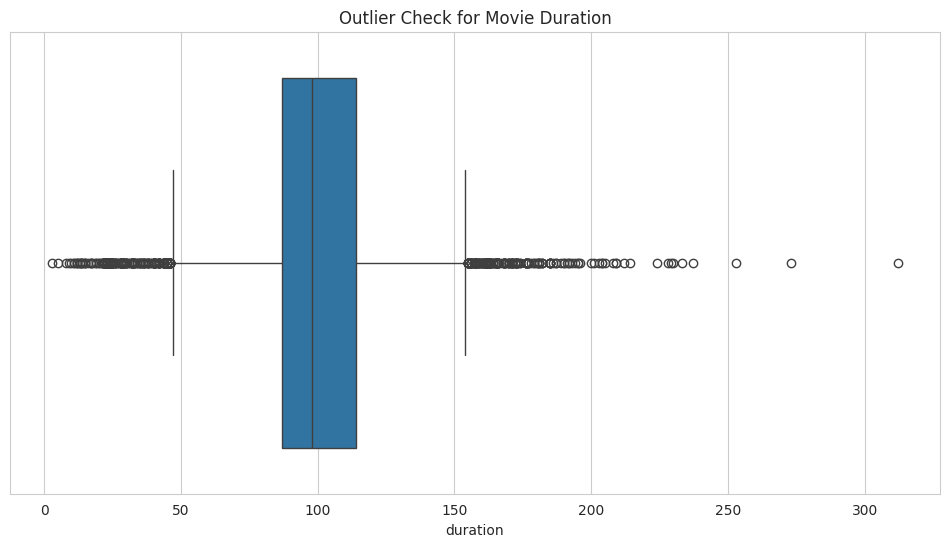

In [ ]:
sns.boxplot(x=movies['duration'])
plt.title("Outlier Check for Movie Duration")
plt.show()

27. The chart shows that July and December are the most active months for adding content to Netflix, with both months exceeding 800 additions.This suggests strategic timing aligned with summer breaks and holiday seasons to maximize viewer engagement.

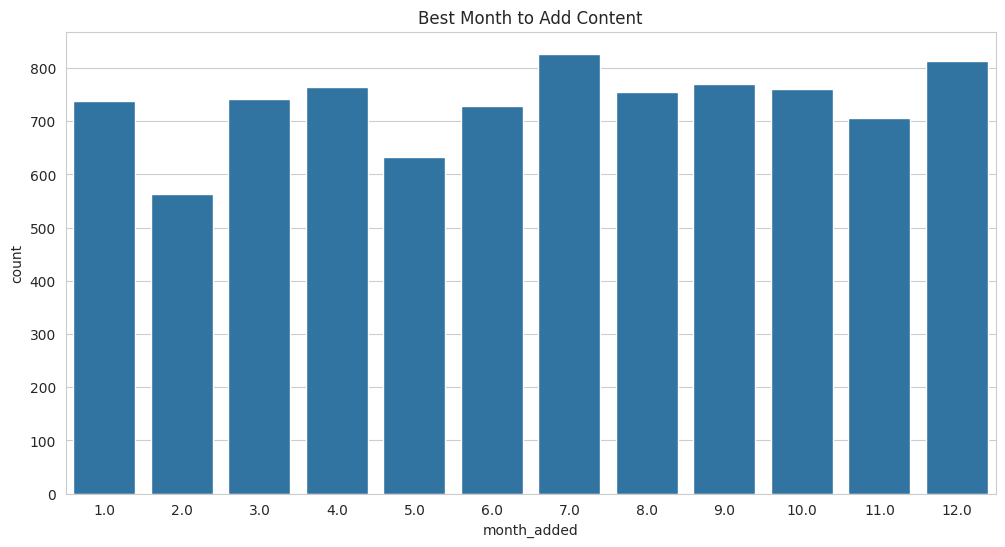

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['month_added'] = df['date_added'].dt.month
sns.countplot(x='month_added', data=df)
plt.title("Best Month to Add Content")
plt.show()